# PokeLance Playground

An interactive walkthrough of PokeLance. Download this notebook (top of the rendered page)
and run it locally with `pip install pokelance jupyter`, or read along here.

Covers: creating a client, the `get_*`/`fetch_*` pattern, `getch_data`, caching, error
handling, and downloading a sprite.

## 1. Setup

Jupyter already runs an event loop per cell via `IPython`'s asyncio integration, so `await`
works directly at the top level of a cell — no `asyncio.run(...)` boilerplate needed here.

In [24]:
from IPython.display import display, Markdown
from pokelance import PokeLance

client = PokeLance(cache_endpoints=True)
await client.wait_until_ready()
display(Markdown(f"Ping: {await client.ping():.2f} ms"))

[2026-07-26 23:44:39,534] | D:\projects\PokeLance\pokelance\client.py:160 | INFO | Using cache size: 100
[2026-07-26 23:44:39,535] | D:\projects\PokeLance\pokelance\client.py:166 | INFO | Setup complete
[2026-07-26 23:44:39,536] | D:\projects\PokeLance\pokelance\client.py:317 | INFO | Waiting until ready...
[2026-07-26 23:44:39,593] | D:\projects\PokeLance\pokelance\http\__init__.py:99 | INFO | Loaded Extension utility endpoints (11/11)
[2026-07-26 23:44:39,613] | D:\projects\PokeLance\pokelance\http\__init__.py:99 | INFO | Loaded Extension machine endpoints (8/11)
[2026-07-26 23:44:39,622] | D:\projects\PokeLance\pokelance\http\__init__.py:99 | INFO | Loaded Extension evolution endpoints (4/11)
[2026-07-26 23:44:39,639] | D:\projects\PokeLance\pokelance\http\__init__.py:99 | INFO | Loaded Extension encounter endpoints (3/11)
[2026-07-26 23:44:39,641] | D:\projects\PokeLance\pokelance\http\__init__.py:99 | INFO | Loaded Extension contest endpoints (2/11)
[2026-07-26 23:44:39,646] | D:\

Ping: 0.02 ms

## 2. Fetching your first resource

`fetch_*` checks the cache first, then falls back to the network. See the
[Fetching Data guide](../fetching_data.md) for the full pattern.

In [25]:
berry = await client.berry.fetch_berry("cheri")
display(Markdown(f"### Berry: {berry.name} (ID: {berry.id})"))
display(Markdown(f"- Growth Time: {berry.growth_time}"))
display(Markdown(f"- Flavors: {', '.join([f'{flavor.flavor.name} ({flavor.potency})' for flavor in berry.flavors])}"))

### Berry: cheri (ID: 1)

- Growth Time: 3

- Flavors: spicy (10), dry (0), sweet (0), bitter (0), sour (0)

In [26]:
# Second call is served entirely from cache - no network request is made.
cached = client.berry.get_berry("cheri")
display(Markdown(f"Cached Berry is the same object: {cached is berry}"))
display(Markdown(f"Cached Berry is equal to the original: {cached == berry}"))
display(Markdown(f"Cached Berry: {cached.name} (ID: {cached.id})"))

Cached Berry is the same object: True

Cached Berry is equal to the original: True

Cached Berry: cheri (ID: 1)

## 3. `getch_data` across extensions

Useful when the extension/category isn't known until runtime (e.g. a generic lookup
command). See [Fetching Data](../fetching_data.md#one-call-for-any-extension-getch_data).

In [27]:
from pokelance.constants import ExtensionEnum
from pokelance.models import Pokemon

pikachu: Pokemon = await client.getch_data(ExtensionEnum.Pokemon, "pokemon", "pikachu")

display(Markdown(f"### Pokemon: {pikachu.name} (ID: {pikachu.id})"))
display(Markdown(f"- Types: {', '.join([t.type.name for t in pikachu.types])}"))

### Pokemon: pikachu (ID: 25)

- Types: electric

## 4. Handling a typo gracefully

`ResourceNotFound` carries `.suggestions`, computed with `difflib` against every known
name/id for that category. See [Error Handling](../error_handling.md).

In [28]:
from pokelance.exceptions import ResourceNotFound

await client.wait_until_ready()  # populate endpoint registries so suggestions work

try:
    await client.pokemon.fetch_pokemon("pikachuu")
except ResourceNotFound as exc:
    display(Markdown(f"### Error: {exc.message}"))
    display(Markdown(f"Did you mean: {', '.join(exc.suggestions)}"))

[2026-07-26 23:44:40,113] | D:\projects\PokeLance\pokelance\client.py:317 | INFO | Waiting until ready...
[2026-07-26 23:44:40,113] | D:\projects\PokeLance\pokelance\client.py:320 | INFO | Ready!


### Error: Resource not found.

Did you mean: pikachu, pichu, pikachu-phd, pikachu-gmax, pikachu-libre, pikachu-belle, pikachu-unova-cap, pikachu-starter, pikachu-cosplay, pachirisu

## 5. Downloading a sprite

`get_image_async` is backed by its own async LRU cache. In a notebook we can render the raw
bytes straight into a rich `Image` output. See [Media](../media.md).

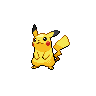

In [29]:
from IPython.display import Image, display

sprite_bytes = await client.get_image_async(pikachu.sprites.front_default)
display(Image(data=sprite_bytes))

## 5b. Playing a cry

`IPython.display.Audio` renders a real HTML5 audio player from raw bytes, no temp file
needed — handy alongside `Image` for a richer, more interactive playground than plain
`print(...)` output. See [Media](../media.md#fetching-a-cry).

In [30]:
from IPython.display import Audio, display

cry_bytes = await client.get_audio_async(pikachu.cries.latest)
display(Audio(data=cry_bytes, autoplay=False))

## 6. Serializing to plain data

Every model supports `.to_dict()` (recursively converts nested `attrs` models and enums) and
`.raw` (the untouched JSON PokéAPI returned).

In [31]:
import json

display(Markdown(f"### Berry JSON:\n```json\n{json.dumps(berry.to_dict(), indent=2, default=str)}\n```"))

### Berry JSON:
```json
{
  "id": 1,
  "name": "cheri",
  "growth_time": 3,
  "max_harvest": 5,
  "natural_gift_power": 60,
  "size": 20,
  "smoothness": 25,
  "soil_dryness": 15,
  "firmness": {
    "name": "soft",
    "url": "https://pokeapi.co/api/v2/berry-firmness/2/"
  },
  "flavors": [
    {
      "potency": 10,
      "flavor": {
        "name": "spicy",
        "url": "https://pokeapi.co/api/v2/berry-flavor/1/"
      }
    },
    {
      "potency": 0,
      "flavor": {
        "name": "dry",
        "url": "https://pokeapi.co/api/v2/berry-flavor/2/"
      }
    },
    {
      "potency": 0,
      "flavor": {
        "name": "sweet",
        "url": "https://pokeapi.co/api/v2/berry-flavor/3/"
      }
    },
    {
      "potency": 0,
      "flavor": {
        "name": "bitter",
        "url": "https://pokeapi.co/api/v2/berry-flavor/4/"
      }
    },
    {
      "potency": 0,
      "flavor": {
        "name": "sour",
        "url": "https://pokeapi.co/api/v2/berry-flavor/5/"
      }
    }
  ],
  "item": {
    "name": "cheri-berry",
    "url": "https://pokeapi.co/api/v2/item/126/"
  },
  "natural_gift_type": {
    "name": "fire",
    "url": "https://pokeapi.co/api/v2/type/10/"
  }
}
```

## 7. Cleaning up

Always close a client you created without an `async with` block once you're done with it.

In [32]:
await client.close()

[2026-07-26 23:44:40,191] | D:\projects\PokeLance\pokelance\client.py:198 | WARNING | Closing session!


---

Where to next:

- [Caching In Depth](../caching.md) — persist an entire category to disk as JSON
- [Extensions Reference](../extensions.md) — every category this same pattern applies to
- [Discord Bot recipe](discord_bot.md) / [FastAPI recipe](fastapi.md) — full integrations